In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras import Sequential
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [4]:
df=pd.read_csv("agnews.csv")

In [5]:
df.shape

(120000, 3)

In [6]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
df.tail()

,Class Index,Title,Description
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
119999,2,Nets get Carter from Raptors,INDIANAPOLIS -- All-Star Vince Carter was trad...


In [8]:
df = df[0:20000]

In [9]:
df.tail()

,Class Index,Title,Description
19995,1,Iraqi captors set new conditions,A STATEMENT purportedly from the captors of tw...
19996,1,"The Region: Wrong, yet winning","On the anniversary of September 11, a curious ..."
19997,2,Braves Top Phillies 3-1 (AP),AP - Replacement starter Travis Smith pitched ...
19998,1,More PE Time May Fight Child Obesity,Just an extra hour of exercise a week could si...
19999,4,Mathematical Mystery Believed to Have Been Solved,One of the seven great unsolved mysteries of m...


In [10]:
df.reset_index(drop = True, inplace = True)

In [11]:
for i in range(10):
    print(df['Description'][i],'-', df['Class Index'][i])
    print()

Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. - 3

Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market. - 3

Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. - 3

Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday. - 3

AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections. - 3

Reuters - Stocks ended slightly higher on Friday\but stayed near lows for the year as oil prices surged past  #36;46\a barr

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  20000 non-null  int64 
 1   Title        20000 non-null  object
 2   Description  20000 non-null  object
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [13]:
df.describe(include='all')

,Class Index,Title,Description
count,20000.000000,20000,20000
unique,NaN,19020,19781
top,NaN,SI.com,Evidence from busy rovers suggests one-time pr...
freq,NaN,13,4
mean,2.484500,NaN,NaN
std,1.133633,NaN,NaN
min,1.000000,NaN,NaN
25%,1.000000,NaN,NaN
50%,2.000000,NaN,NaN
75%,4.000000,NaN,NaN


In [14]:
df.isna().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

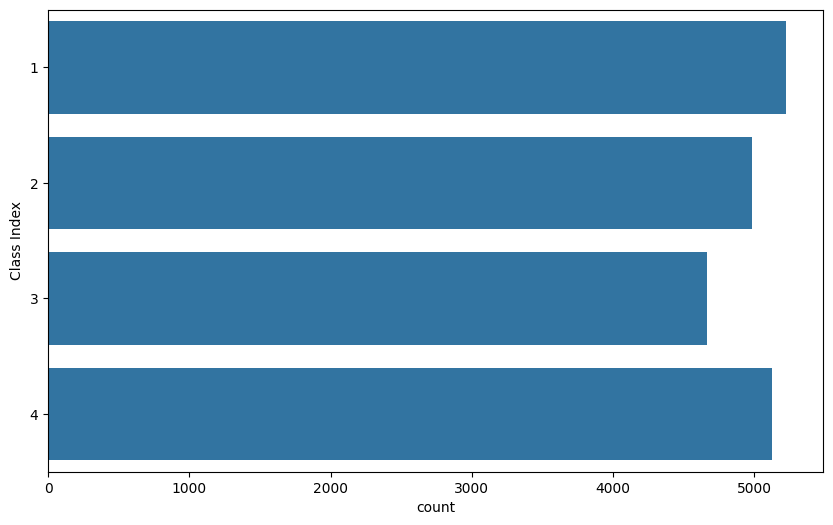

In [16]:
plt.figure(figsize = (10,6))
sns.countplot(y = df['Class Index'])
plt.show()

In [17]:
def preprocess(sentence):
    text = re.sub(r"[^a-zA-Z0-9]"," ",sentence).split()
    words = [x.lower() for x in text if x not in stopwords.words('english')]
    lemma = WordNetLemmatizer()
    word = [lemma.lemmatize(word,'v') for word in words ]
    word = ' '.join(word)
    return word

In [18]:
df['Description'] = df['Description'].apply(preprocess)

In [19]:
for i in range(10):
    print(df['Description'][i],'-', df['Class Index'][i])
    print()

reuters short sellers wall street dwindle band ultra cynics see green - 3

reuters private investment firm carlyle group reputation make well time occasionally controversial play defense industry quietly place bet another part market - 3

reuters soar crude price plus worry economy outlook earnings expect hang stock market next week depth summer doldrums - 3

reuters authorities halt oil export flow main pipeline southern iraq intelligence show rebel militia could strike infrastructure oil official say saturday - 3

afp tearaway world oil price topple record strain wallets present new economic menace barely three months us presidential elections - 3

reuters stock end slightly higher friday stay near low year oil price surge past 36 46 barrel offset positive outlook computer maker dell inc dell o - 3

ap assets nation retail money market mutual fund fell 36 1 17 billion latest week 36 849 98 trillion investment company institute say thursday - 3

usatoday com retail sales bounce back b

In [20]:
X = df['Description']
y = df['Class Index']

In [21]:
encoder = LabelBinarizer()
y = encoder.fit_transform(y)

In [22]:
labels = encoder.classes_
labels

array([1, 2, 3, 4])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20)

In [24]:
tokenizer = Tokenizer(num_words=5000)

In [25]:
tokenizer.fit_on_texts(X)

In [26]:
vocab_size = len(tokenizer.word_index) + 1

In [27]:
def text_encoding(txt):
    encoded_docs = tokenizer.texts_to_sequences(txt)
    padded_sequence = pad_sequences(encoded_docs, maxlen=128)    
    return padded_sequence

In [28]:
X_train = text_encoding(X_train)
X_test = text_encoding(X_test)

In [29]:
model = Sequential()
model.add(layers.Embedding(vocab_size, 128))
model.add(layers.GRU(128,  return_sequences=True))
model.add(layers.Dropout(0.2))
model.add(layers.GRU(128))
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(4, activation='softmax'))

In [31]:
model.build((None,X_train.shape[1]))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 128, 128)            │       2,989,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 128, 128)            │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 128)                 │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,196,100 (12.19 MB)

 Trainable params: 3,196,100 (12.19 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [34]:
model.fit(X_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 94s 224ms/step - accuracy: 0.7498 - loss: 0.6367 - val_accuracy: 0.8744 - val_loss: 0.3758
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 203ms/step - accuracy: 0.8967 - loss: 0.3141 - val_accuracy: 0.8656 - val_loss: 0.4086
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 207ms/step - accuracy: 0.9270 - loss: 0.2277 - val_accuracy: 0.8656 - val_loss: 0.4330
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 84s 209ms/step - accuracy: 0.9415 - loss: 0.1774 - val_accuracy: 0.8509 - val_loss: 0.5038
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 79s 197ms/step - accuracy: 0.9522 - loss: 0.1459 - val_accuracy: 0.8500 - val_loss: 0.5233
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 80s 201ms/step - accuracy: 0.9670 - loss: 0.1029 - val_accuracy: 0.8541 - val_loss: 0.6055
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 203ms/step - accuracy: 0.9695 - loss: 0.0896 - val_accuracy: 0.8591 - val_loss: 0.6088
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 69s 172ms/step - accuracy: 0.9761 - loss: 0

In [35]:
y_pred = model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step


In [36]:
y_pred = [np.argmax(i) for i in y_pred]

In [37]:
y_test = [np.argmax(i) for i in y_test]

In [38]:
accuracy_score(y_test, y_pred)

0.84675

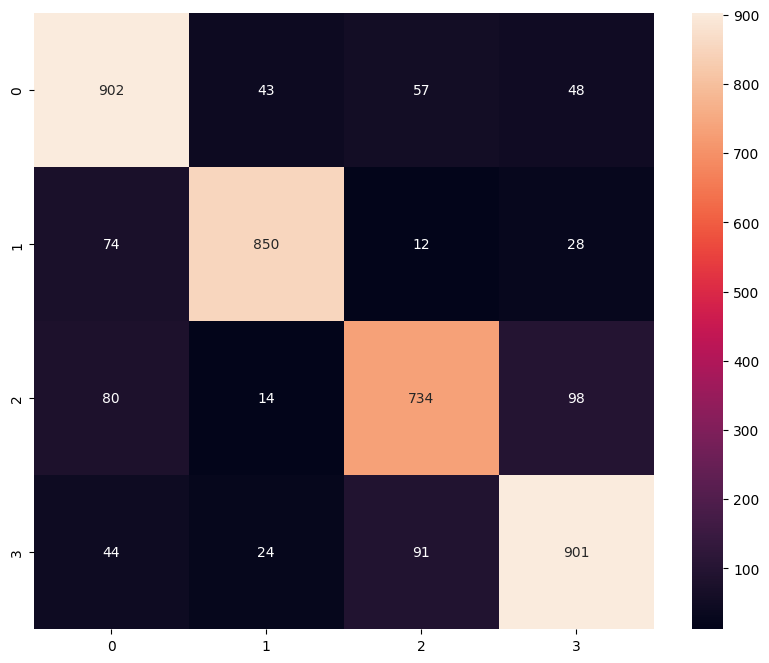

In [39]:
plt.figure(figsize = (10,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')
plt.show()

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1050
           1       0.91      0.88      0.90       964
           2       0.82      0.79      0.81       926
           3       0.84      0.85      0.84      1060

    accuracy                           0.85      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.85      0.85      0.85      4000

